In [2]:
class Chance_Constraint:
    def __init__(self):
        """
        Pr (x1e1 + x2e2 < 1) > 1-delta
        """
        self.c_dim = 4 # mu1, sigma1, mu2, sigma2
        self.sampling_range = [[0,1], [0,1]]
        self.n_dim = 2


In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import copy

def Geletu_indicator(s, tau=0.02, m1=1, m2=1):
    return (1+m1*tau)/(1+m2*tau*np.exp(-s/tau))

def quartic_indicator(s, epsilon=0.1):
    s = copy.deepcopy(s)
    s[s<-epsilon] = 1
    s[s>epsilon] = 0
    y = s[(s>=-epsilon) & (s<=epsilon)] 
    y = 15/16*(-1/5*(y/epsilon)**5+2/3*(y/epsilon)*3-y/epsilon+8/15)
    s[(s>=-epsilon) & (s<=epsilon)]  = y
    return s

def chance_constraint(delta = 0.1,sample_size = 100, resolution=100):
    # Generate a grid of (x1, x2) values
    x1_values = np.linspace(0, 1, resolution)
    x2_values = np.linspace(0, 1, resolution)
    x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)

    # Initialize the matrix to store the probabilities
    # Sampling e1, e2
    e1 = np.random.normal(0, 1, sample_size)
    e2 =  np.random.normal(0, 1, sample_size)

    # Calculate the probability for each (x1, x2)
    x1 = x1_grid.reshape([resolution,resolution,1])
    x2 = x2_grid.reshape([resolution,resolution,1])
    e1 = e1.reshape([1,1,sample_size])
    e2 = e2.reshape([1,1,sample_size])
    z = (x1) * e1 + (x2) * e2 - 1 # constraint violation
    z = np.sort(z, axis=-1)
    VaR_idx = int((1 - delta) * sample_size)
    var_matrix = np.mean(z<0, axis=-1)
    cvar_matrix = np.mean(z[:,:,VaR_idx:], axis=-1)
    # Calculate the probability that z < 0
    psi_matrix = np.mean(Geletu_indicator(z), axis=-1)
    # qua_matrix = np.mean(quartic_indicator(z), axis=-1)

    return var_matrix, cvar_matrix, psi_matrix, x1_grid, x2_grid

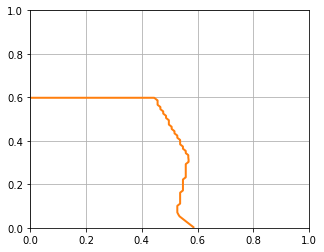

In [136]:
from matplotlib.lines import Line2D
delta_list = [0.1]
sample_list = [12]
plt.figure(figsize=(5, 4))
for i, delta in enumerate(delta_list):
    for j, sample_size in enumerate(sample_list):
        # delta = 0.05
        # sample_size = 100
        resolution= 100
        inverse_cdf_value = norm.ppf(1 - delta)
        # Boundary for the constraint
        theta = np.linspace(0, np.pi/2, resolution)
        radius = 1 / inverse_cdf_value
        xcc = radius * np.cos(theta)
        ycc = radius * np.sin(theta)
        cc_matrix, cvar_matrix, psi_matrix, x1_grid, x2_grid = chance_constraint(delta, sample_size, resolution)

        # plt.subplot(len(delta_list),len(sample_list),i*len(sample_list)+j+1)
        # plt.plot(xcc, ycc, c='C0', lw=2)
        plt.contour(x1_grid, x2_grid, cc_matrix, levels=[1-delta],colors='C1', linewidths=2)  # Boundary for 1-delta
        # plt.contour(x1_grid, x2_grid, cc_matrix, levels=[0.9999],colors='C2', linewidths=2)  # Boundary for 1-delta
        # plt.contour(x1_grid, x2_grid, cvar_matrix, levels=[delta],colors='C3', linewidths=2)  # Boundary for 1-delta
        # plt.contour(x1_grid, x2_grid, psi_matrix, levels=[delta],colors='C4', linewidths=2)  # Boundary for 1-delta
        
        # rho = 1.5
        # xl = np.linspace(0,1,resolution)
        # plt.plot(xl, 1/rho-xl, c='C5', lw=2)
        # plt.title(f'Risk Level {delta} and {sample_size} Samples', fontsize=14)
        # plt.xlim([0,0.8])
        # plt.ylim([0,0.8])
        plt.grid(True)

legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Exact'),
                Line2D([0], [0], color='C1', lw=2, label=f'Sample average'),]
                # Line2D([0], [0], color='C2', lw=2, label=f'Scenario approach'),
                # Line2D([0], [0], color='C3', lw=2, label=f'CVaR approximation'),
                # Line2D([0], [0], color='C4', lw=2, label=f'Smooth approximation'),
                # Line2D([0], [0], color='C5', lw=2, label=f'Linear approximation')]
# plt.legend(handles=legend_elements,fontsize=14,  bbox_to_anchor=(0.6, -0.05), ncol=3)
plt.show()